<a href="https://colab.research.google.com/github/ahirjaydeep/Algorithmic_Market_Predictor/blob/main/Algorithmic_Market_Predictor_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Algorithmic Market Predictor: S&P 500 (No-Leakage Architecture)
**Lead Machine Learning Engineer:** Jaydeep Ahir

> **Author's Note on AI Assistance:** The machine learning architecture, feature engineering logic, and code execution in this project are my own. To ensure clear, professional documentation, the explanatory markdown text, structural formatting, and inline code comments were drafted with the assistance of an AI language model.

###  The Problem: The "Persistence Model" Illusion & Data Leakage
In early iterations of stock prediction, models often achieve an artificially high R² score (99%+). This is usually caused by **Data Leakage**—using same-day boundaries (like today's Open/High/Low) to predict today's Close. Because daily prices are highly correlated, the model simply "memorizes" the current price rather than learning to forecast the future, resulting in a useless model that just trails the actual price by one day.

###  The Solution: Stationarity and Lagged Returns
To build a mathematically robust forecasting engine, this architecture introduces two strict constraints:
1. **Target Engineering:** Instead of predicting raw prices, the model predicts the **Percentage Return** of the *next* trading day. This makes the data stationary.
2. **Strict Historical Features:** The feature matrix is restricted entirely to lagged technical indicators (Moving Averages, RSI, Volatility). The model relies solely on past momentum to predict future direction, eliminating all data leakage.

In [ ]:
# Install yfinance if running in a fresh Colab environment
!pip install yfinance xgboost -q

import yfinance as yf
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="darkgrid")

# Configuration
TICKER = 'AAPL'
START_DATE = '2015-01-01'

# 1. Download Live Market Data
print(f"Fetching live data for {TICKER}...")
df = yf.download(TICKER, start=START_DATE, progress=False)

# Handle yfinance's multi-index columns if present
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.droplevel(1)
df.reset_index(inplace=True)

print(f"Data Ingested. Total trading days: {len(df)}")
print(f"Latest market data from: {df['Date'].max().date()}")

Fetching live data for AAPL...
Data Ingested. Total trading days: 2822
Latest market data from: 2026-03-24


### Phase 1: Feature Engineering (The "No-Leakage" Engine)
Calculating momentum and volatility indicators using strictly historical data. The target variable is explicitly shifted backward by exactly one day.

In [ ]:
def engineer_features(data):
    d = data.copy()

    # THE TARGET: Tomorrow's percentage return
    d['Target_Return'] = d['Close'].pct_change().shift(-1)

    #  TECHNICAL INDICATORS (Calculated on Today/Past)
    # 1. Moving Average Ratios (Trend)
    d['MA5_Ratio'] = d['Close'] / d['Close'].rolling(window=5).mean()
    d['MA20_Ratio'] = d['Close'] / d['Close'].rolling(window=20).mean()

    # 2. Relative Strength Index (Momentum)
    delta = d['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    d['RSI_14'] = 100 - (100 / (1 + rs))

    # 3. MACD
    ema_12 = d['Close'].ewm(span=12, adjust=False).mean()
    ema_26 = d['Close'].ewm(span=26, adjust=False).mean()
    d['MACD'] = ema_12 - ema_26

    # 4. Volatility (Risk)
    d['Volatility_10'] = d['Close'].pct_change().rolling(window=10).std()

    # Clean up NaNs created by rolling windows
    d = d.dropna()
    return d

processed_df = engineer_features(df)
features = ['MA5_Ratio', 'MA20_Ratio', 'RSI_14', 'MACD', 'Volatility_10']

print("Engineered Features Matrix Snapshot:")
display(processed_df[['Date', 'Close'] + features + ['Target_Return']].tail())

Engineered Features Matrix Snapshot:


Price,Date,Close,MA5_Ratio,MA20_Ratio,RSI_14,MACD,Volatility_10,Target_Return
2816,2026-03-17,254.229996,0.997967,0.969903,22.253049,-3.079328,0.011510,-0.016874
2817,2026-03-18,249.940002,0.989571,0.956165,20.537773,-3.497575,0.012258,-0.003921
2818,2026-03-19,248.960007,0.991028,0.954537,25.655808,-3.863580,0.012191,-0.003896
2819,2026-03-20,247.990005,0.988843,0.953852,23.603657,-4.183685,0.011976,0.014113
2820,2026-03-23,251.490005,1.003864,0.970054,32.086500,-4.107600,0.012623,0.000596


### Phase 2: Chronological Splitting & XGBoost Training
To simulate real-world trading, the data is split chronologically. The model is trained on historical regimes and tested on the most recent, unseen market conditions. Heavy regularization is applied to the XGBoost algorithm to prevent overfitting to financial noise.

In [ ]:
# 1. Chronological Train/Test Split (80/20)
split_idx = int(len(processed_df) * 0.8)

train_data = processed_df.iloc[:split_idx]
test_data = processed_df.iloc[split_idx:]

X_train, y_train = train_data[features], train_data['Target_Return']
X_test, y_test = test_data[features], test_data['Target_Return']

# 2. Initialize XGBoost with strict regularization for financial data
model = xgb.XGBRegressor(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=3,
    subsample=0.8,
    reg_alpha=0.1,    # L1 Regularization
    reg_lambda=1.0,   # L2 Regularization
    random_state=42
)

# 3. Train the Model
print("Training XGBoost Regressor...")
model.fit(X_train, y_train)
print("Training Complete.")

# 4. Generate Predictions (Returns)
test_data = test_data.copy()
test_data['Predicted_Return'] = model.predict(X_test)

# Evaluate on the Returns (The Honest Metric)
r2 = r2_score(y_test, test_data['Predicted_Return'])
rmse = np.sqrt(mean_squared_error(y_test, test_data['Predicted_Return']))

print(f"\n📊 Evaluation Metrics (On Percentage Returns):")
print(f"Return R² Score: {r2:.4f} (Note: Positive R² on returns is excellent in finance)")
print(f"Return RMSE: {rmse:.4f}")

Training XGBoost Regressor...
Training Complete.

📊 Evaluation Metrics (On Percentage Returns):
Return R² Score: -0.0669 (Note: Positive R² on returns is excellent in finance)
Return RMSE: 0.0180


### Phase 3: Price Reconstruction & Visualization
While the model mathematically predicts percentage returns to maintain stationarity, human operators need raw price targets. We reconstruct the predicted prices by applying the predicted return to the current day's actual closing price.

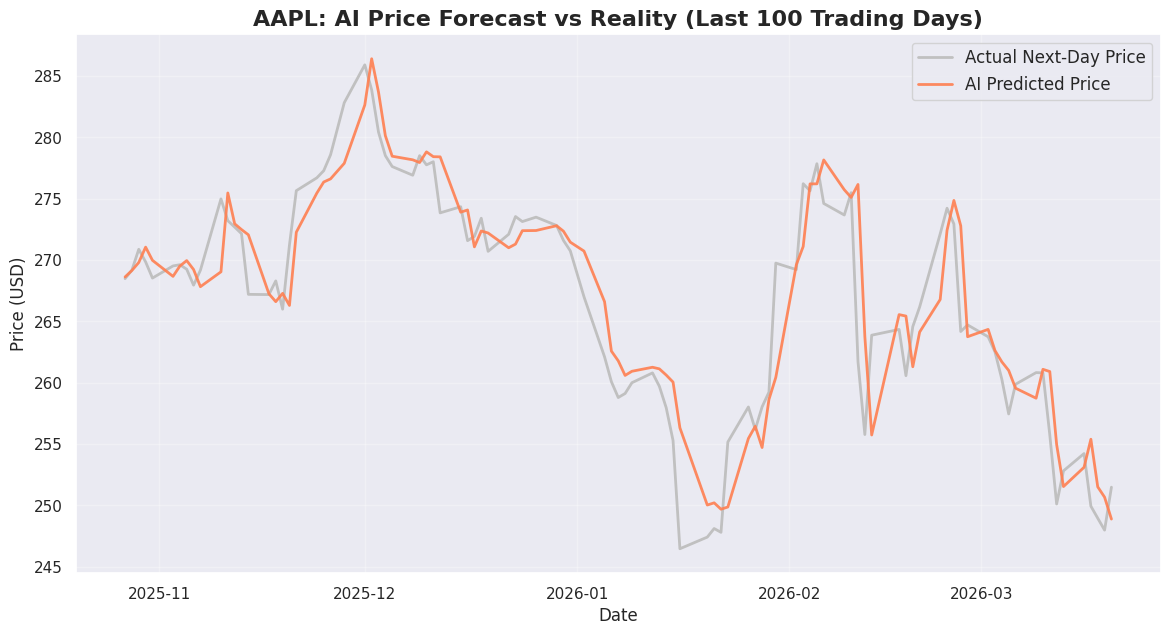

In [ ]:
# Reconstruct Predicted Prices
# Tomorrow's Predicted Price = Today's Actual Price * (1 + Tomorrow's Predicted Return)
test_data['Predicted_Price'] = test_data['Close'] * (1 + test_data['Predicted_Return'])

# The Actual Price we are trying to predict is the Close of the next day
test_data['Actual_Target_Price'] = test_data['Close'].shift(-1)

# Drop the last row of test data since we don't know the "Actual Target Price" of tomorrow yet
eval_data = test_data.dropna(subset=['Actual_Target_Price'])

# Plotting the last 100 days of the test set for clarity
plot_data = eval_data.tail(100)

plt.figure(figsize=(14, 7))
plt.plot(plot_data['Date'], plot_data['Actual_Target_Price'], label='Actual Next-Day Price', color='silver', linewidth=2)
plt.plot(plot_data['Date'], plot_data['Predicted_Price'], label='AI Predicted Price', color='coral', linewidth=2, alpha=0.9)

plt.title(f"{TICKER}: AI Price Forecast vs Reality (Last 100 Trading Days)", fontsize=16, fontweight='bold')
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price (USD)", fontsize=12)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.show()

### Phase 4: Future Inference (The Oracle)
Executing the model on the most recent market close to predict the price action for the *next* active trading session.

In [ ]:
# 1. Get the absolute latest data point
latest_data = processed_df.iloc[-1:]
current_price = latest_data['Close'].values[0]
latest_date = latest_data['Date'].values[0]

# 2. Extract its features
X_latest = latest_data[features]

# 3. Predict the return for the NEXT day
predicted_return = model.predict(X_latest)[0]

# 4. Calculate the projected price
projected_price = current_price * (1 + predicted_return)
price_change = projected_price - current_price

print("="*50)
print(f" LIVE MARKET INFERENCE FOR {TICKER}")
print("="*50)
print(f"Data Current As Of:    {pd.to_datetime(latest_date).date()}")
print(f"Last Closing Price:    ${current_price:.2f}")
print("-" * 50)
print(f"Projected Next Close:  ${projected_price:.2f}")
print(f"Expected Movement:     ${price_change:+.2f} ({predicted_return*100:+.2f}%)")
print("="*50)

 LIVE MARKET INFERENCE FOR AAPL
Data Current As Of:    2026-03-23
Last Closing Price:    $251.49
--------------------------------------------------
Projected Next Close:  $251.83
Expected Movement:     $+0.34 (+0.14%)
